In [42]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

In [43]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [45]:
df.shape

(8807, 12)

In [46]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [47]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [48]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [49]:
df["director"]=df["director"].fillna("unknown")
df["cast"]= df["cast"].fillna("unknown")
df["country"]= df["country"].fillna("unknown")
df["rating"]= df["rating"].fillna(df["rating"].mode()[0])

df= df.dropna(subset=["date_added"])

In [50]:
df.duplicated().sum()

0

In [51]:
df["date_added"]= pd.to_datetime(df["date_added"],
                                 format="mixed",
                                 errors="coerce"
                                )

In [52]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

In [53]:
df.to_csv("netflix_cleaned.csv", index=False)

In [54]:
type_count=df["type"].value_counts()

type_count

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [55]:
top_countries= df["country"].value_counts().head(10)

top_countries

country
United States     2812
India              972
unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [56]:
df["Year Added"]= df["date_added"].dt.year

titles_per_year = df["Year Added"].value_counts().sort_index()

titles_per_year

Year Added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [57]:
genres= df["listed_in"].str.split(",").explode()

top_genres= genres.value_counts().head(10)

top_genres

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64

In [58]:
ratings= df["rating"].value_counts()

ratings

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [59]:
release_year= df["release_year"].value_counts().sort_index()

release_year

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

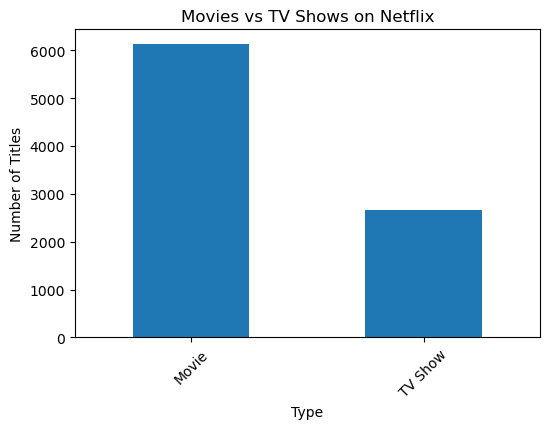

In [60]:
import matplotlib.pyplot as plt

type_count.plot(kind="bar", figsize=(6,4))
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

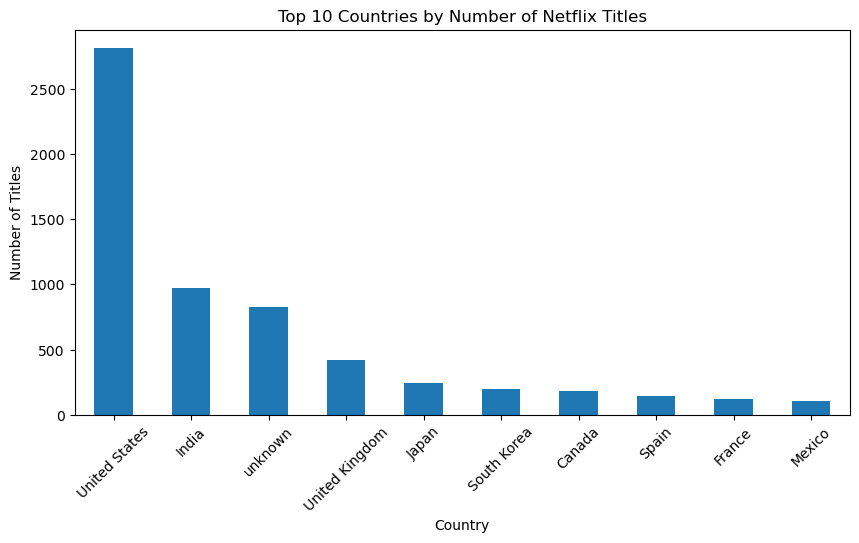

In [61]:
top_countries= df["country"].value_counts().head(10)

top_countries.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

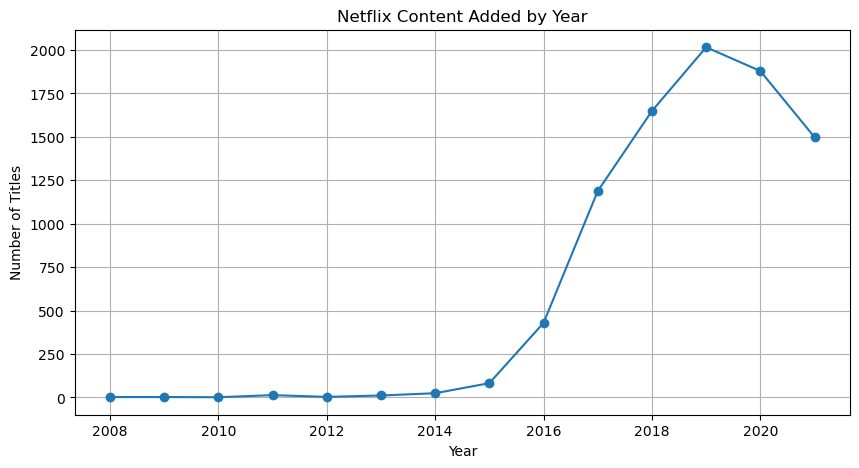

In [62]:
titles_per_year.plot(kind="line", marker ="o", figsize=(10,5))
plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

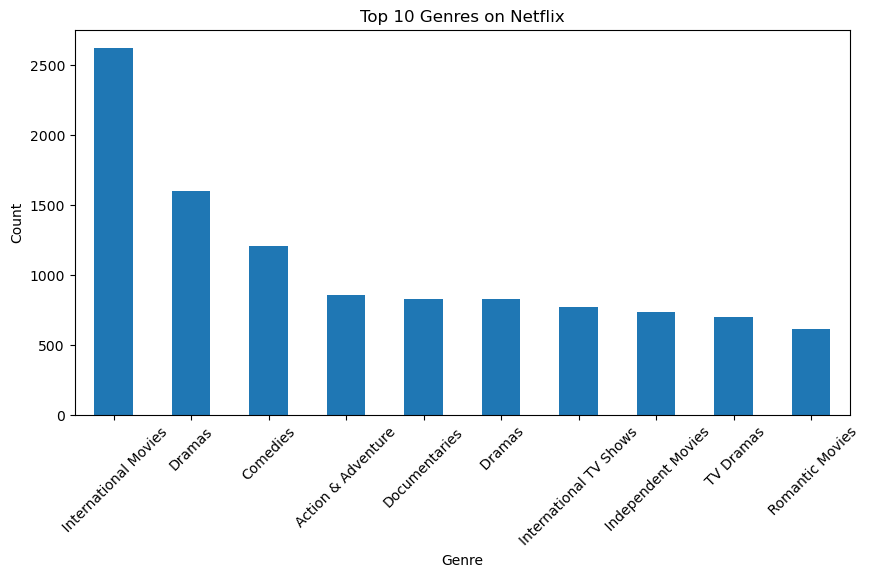

In [63]:
top_genres.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

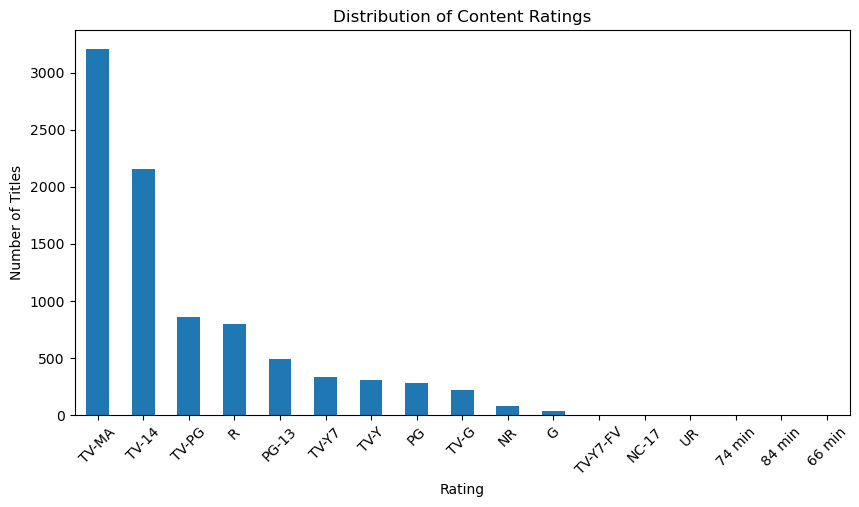

In [64]:
ratings.plot(kind="bar", figsize=(10,5))
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

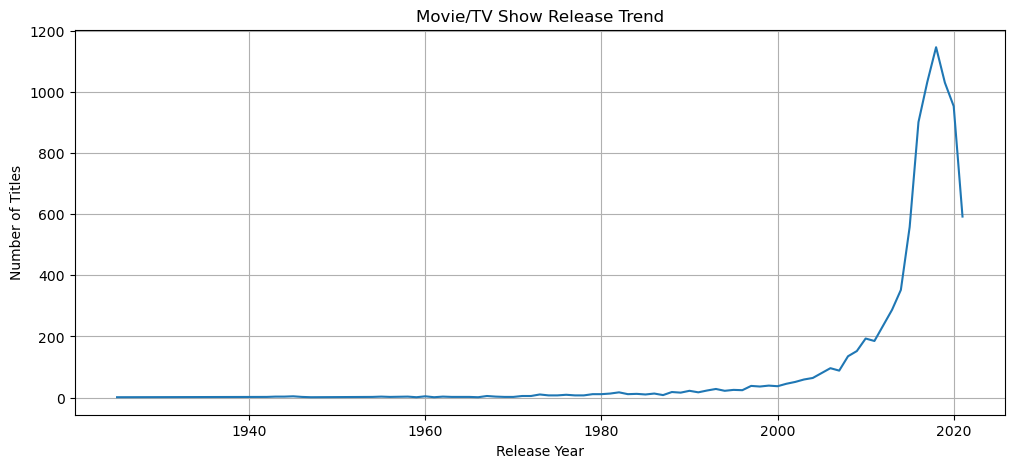

In [66]:
release_year.plot(figsize=(12,5))
plt.title("Movie/TV Show Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

## Insight 1

Movies dominate Netflix's content library.
The Movies vs TV Shows bar chart shows that Netflix has significantly more movies than TV shows, indicating that movies make up the majority of the platform's content.

## Insight 2

The United States contributes the most Netflix titles.
The Top 10 Countries chart shows that the United States has the largest number of titles, making it the leading content producer on Netflix.

## Insight 3

Netflix experienced rapid growth in content releases until 2018.
The line chart of release years shows that the number of titles increased steadily over time, peaked around 2018, and then declined slightly in the following years.

## Insight 4

TV-MA is the most common content rating.
The ratings chart indicates that TV-MA appears more frequently than other ratings, suggesting that Netflix has a large amount of content intended for mature audiences.

## Insight 5

Drama is one of the most common genres on Netflix.
The Top Genres chart shows that drama-related content appears more often than other genres, highlighting its popularity on the platform.